# Feature Extraction - Figshare Dataset

**Objective:** Extract multi-domain features from windowed sensor data for FoG detection.

**Features extracted:**
- Time-domain: mean, std, skewness, kurtosis, RMS, median, IQR, cadence
- Frequency-domain: PSD peak, total energy, band powers, freezing index
- Wavelet: energy per level, entropy
- Nonlinear: sample entropy, fractal dimension

**Pipeline:**
1. Load windowed LOSO splits
2. Initialize the feature extractor
3. Process all folds: extract features directly from raw windows → save CSVs
4. Analyze extracted features with visualizations

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm

from features import FeatureExtractor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Windowed Data

In [2]:
# Load binary LOSO splits
data_path = Path('../../outputs/datasets_csv/figshare_loso_windows_binary.pkl')

with open(data_path, 'rb') as f:
    loso_splits = pickle.load(f)

print(f"✅ Loaded {len(loso_splits)} LOSO folds")
print(f"   Total train windows: {sum([len(fold['y_train']) for fold in loso_splits]):,}")
print(f"   Total test windows: {sum([len(fold['y_test']) for fold in loso_splits]):,}")

✅ Loaded 35 LOSO folds
   Total train windows: 190,706
   Total test windows: 2,840


## 2. Initialize Feature Extractor

Audit-aligned setting: features are extracted directly from raw windowed signals without outlier cleaning or aggressive interpolation.

In [3]:
print("✅ Raw-window feature extraction enabled")
print("   Outlier cleaning: disabled")
print("   Missing-value interpolation: disabled")
print("   Windowed signals are preserved as generated in notebook 02")

✅ Raw-window feature extraction enabled
   Outlier cleaning: disabled
   Missing-value interpolation: disabled
   Windowed signals are preserved as generated in notebook 02


In [4]:
# Feature extractor
SAMPLING_RATE = 128  # Hz for Figshare

extractor = FeatureExtractor(
    sampling_rate=SAMPLING_RATE,
    extract_time=True,
    extract_frequency=True,
    extract_wavelet=True,
    extract_nonlinear=True  # Enabled for robust cross-dataset pipeline
)

# Channel groups for per-sensor magnitude computation
# Figshare: 6 channels — acc (0-2) + gyr (3-5) on lower back
CHANNEL_GROUPS = {
    'acc_lower_back': [0, 1, 2],
    'gyr_lower_back': [3, 4, 5],
}

print("✅ Feature extractor initialized")
print(f"   Sampling rate: {SAMPLING_RATE} Hz")
print(f"   Time-domain: ✅")
print(f"   Frequency-domain: ✅")
print(f"   Wavelet: ✅")
print(f"   Nonlinear: ✅")
print(f"   Channel groups: {list(CHANNEL_GROUPS.keys())}")

✅ Feature extractor initialized
   Sampling rate: 128 Hz
   Time-domain: ✅
   Frequency-domain: ✅
   Wavelet: ✅
   Nonlinear: ✅
   Channel groups: ['acc_lower_back', 'gyr_lower_back']


## 3. Process All LOSO Folds

Extract features from all folds and save to CSV files.

In [5]:
# Output directory
feature_output_dir = Path('../../outputs/figshare_features')
feature_output_dir.mkdir(parents=True, exist_ok=True)

expected_subjects = [fold['test_subject'] for fold in loso_splits]
expected_dirs = {f'fold_subj_{subject}' for subject in expected_subjects}
existing_dirs = {path.name for path in feature_output_dir.glob('fold_subj_*') if path.is_dir()}
stale_dirs = sorted(existing_dirs - expected_dirs)
required_files = [
    'X_train_features.csv',
    'y_train.csv',
    'subjects_train.csv',
    'X_test_features.csv',
    'y_test.csv',
]

print('🚀 Processing all LOSO folds...')
print('=' * 70)
print(f'Expected LOSO folds from notebook 02: {len(expected_subjects)}')
if stale_dirs:
    print(f'⚠️ Stale feature directories detected: {len(stale_dirs)}')
    for name in stale_dirs[:10]:
        print(f'   - {name}')
    if len(stale_dirs) > 10:
        print(f'   ... and {len(stale_dirs) - 10} more')

processed_subjects = []

for fold in tqdm(loso_splits, desc='Processing folds'):
    test_subject = fold['test_subject']

    # 1. Extract features directly from raw windows
    X_train_features = extractor.extract_from_windows(
        fold['X_train'], n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)
    X_test_features = extractor.extract_from_windows(
        fold['X_test'], n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)

    # 2. Save to CSV
    fold_dir = feature_output_dir / f'fold_subj_{test_subject}'
    fold_dir.mkdir(parents=True, exist_ok=True)

    X_train_features.to_csv(fold_dir / 'X_train_features.csv', index=False)
    pd.Series(fold['y_train'], name='label').to_csv(fold_dir / 'y_train.csv', index=False)
    pd.Series(fold['subjects_train'], name='subject').to_csv(fold_dir / 'subjects_train.csv', index=False)
    X_test_features.to_csv(fold_dir / 'X_test_features.csv', index=False)
    pd.Series(fold['y_test'], name='label').to_csv(fold_dir / 'y_test.csv', index=False)

    processed_subjects.append(test_subject)

missing_outputs = []
for subject in expected_subjects:
    fold_dir = feature_output_dir / f'fold_subj_{subject}'
    for filename in required_files:
        if not (fold_dir / filename).exists():
            missing_outputs.append(f'{fold_dir.name}/{filename}')

print('\n' + '=' * 70)
print(f'✅ Feature extraction complete for {len(processed_subjects)} folds')
print(f'📁 Output directory: {feature_output_dir}')
if missing_outputs:
    print(f'❌ Missing output files detected: {len(missing_outputs)}')
    for path in missing_outputs[:10]:
        print(f'   - {path}')
    if len(missing_outputs) > 10:
        print(f'   ... and {len(missing_outputs) - 10} more')
    raise RuntimeError('Figshare feature extraction is incomplete. Re-run notebook 03 to regenerate all expected folds.')
else:
    print('✅ Output validation passed: all expected fold files are present')
print('=' * 70)

🚀 Processing all LOSO folds...
Expected LOSO folds from notebook 02: 35


Processing folds:   0%|          | 0/35 [00:00<?, ?it/s]

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   26.3s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   27.2s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:   29.9s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   30.8s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   33.3s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   35.5s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   37.0s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   40.0s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:   42.2s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   44.4s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:   47.7s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   49.6s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   51.8s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   54.3s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

🚀 Extracting features in parallel (-1 jobs)...


...

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   10.9s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:   13.3s
[Paralle

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 102 out of 120 | elapsed:    5.4s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done 115 out of 120 | elapsed:    5.9s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 120 out of 120 | elapsed:    6.0s finished
Processing folds: 100%|██████████| 35/35 [3:23:44<00:00, 349.29s/it]



✅ Feature extraction complete for 35 folds
📁 Output directory: ..\..\outputs\figshare_features
✅ Output validation passed: all expected fold files are present


## 4. Load Sample Features for Analysis

Load features from the first fold for visualization and analysis.

In [ ]:
# Load one verified fold for analysis
sample_subject = loso_splits[0]['test_subject']
sample_fold_dir = feature_output_dir / f'fold_subj_{sample_subject}'

if not sample_fold_dir.exists():
    available_fold_dirs = sorted(path for path in feature_output_dir.glob('fold_subj_*') if path.is_dir())
    if not available_fold_dirs:
        raise FileNotFoundError('No Figshare feature fold directories were found. Run notebook 03 first.')
    sample_fold_dir = available_fold_dirs[0]
    print('⚠️ Expected first fold directory is missing; using the first available fold for analysis instead.')

X_train_features = pd.read_csv(sample_fold_dir / 'X_train_features.csv')
y_train = pd.read_csv(sample_fold_dir / 'y_train.csv').squeeze()
X_test_features = pd.read_csv(sample_fold_dir / 'X_test_features.csv')
y_test = pd.read_csv(sample_fold_dir / 'y_test.csv').squeeze()

print(f'📊 Loaded features from: {sample_fold_dir.name}')
print(f'   Train: {X_train_features.shape}')
print(f'   Test: {X_test_features.shape}')
print(f'   Features: {X_train_features.shape[1]}')
print(f'\n📋 First 10 features:')
for i, col in enumerate(X_train_features.columns[:10], 1):
    print(f'   {i}. {col}')

📊 Loaded features from: fold_subj_S01
   Train: (8211, 225)
   Test: (120, 225)
   Features: 225

📋 First 10 features:
   1. ch0_mean
   2. ch0_std
   3. ch0_skew
   4. ch0_kurt
   5. ch0_median
   6. ch0_iqr
   7. ch0_rms
   8. ch0_peak_to_peak
   9. ch0_zero_crossing_rate
   10. ch0_psd_peak_freq


## 5. Feature Statistics

In [7]:
# Statistical summary
print("📈 Feature Statistics (Train Set):")
print(X_train_features.describe())

📈 Feature Statistics (Train Set):
          ch0_mean      ch0_std     ch0_skew     ch0_kurt   ch0_median  \
count  8211.000000  8211.000000  8211.000000  8211.000000  8211.000000   
mean      0.026147     0.240728    -0.005539     1.778551     0.027884   
std       0.116651     0.174043     0.668949     3.973181     0.114789   
min      -0.334082     0.007830    -6.782568    -1.078672    -0.336892   
25%      -0.058782     0.110833    -0.271545     0.735103    -0.056815   
50%       0.023789     0.206547    -0.029803     1.003728     0.027935   
75%       0.107742     0.323212     0.221468     1.325999     0.106928   
max       0.465198     1.600837     5.898845    77.583217     0.456656   

           ch0_iqr      ch0_rms  ch0_peak_to_peak  ch0_zero_crossing_rate  \
count  8211.000000  8211.000000       8211.000000             8211.000000   
mean      0.199929     0.273679          1.505568                0.118654   
std       0.138292     0.166223          1.409936                0.0

## 6. Feature Distributions: Freeze vs No Freeze

Compare key features between Freeze and No Freeze windows.

📊 Class Distribution:
   No Freeze: 6,580 windows (80.1%)
   Freeze: 1,631 windows (19.9%)


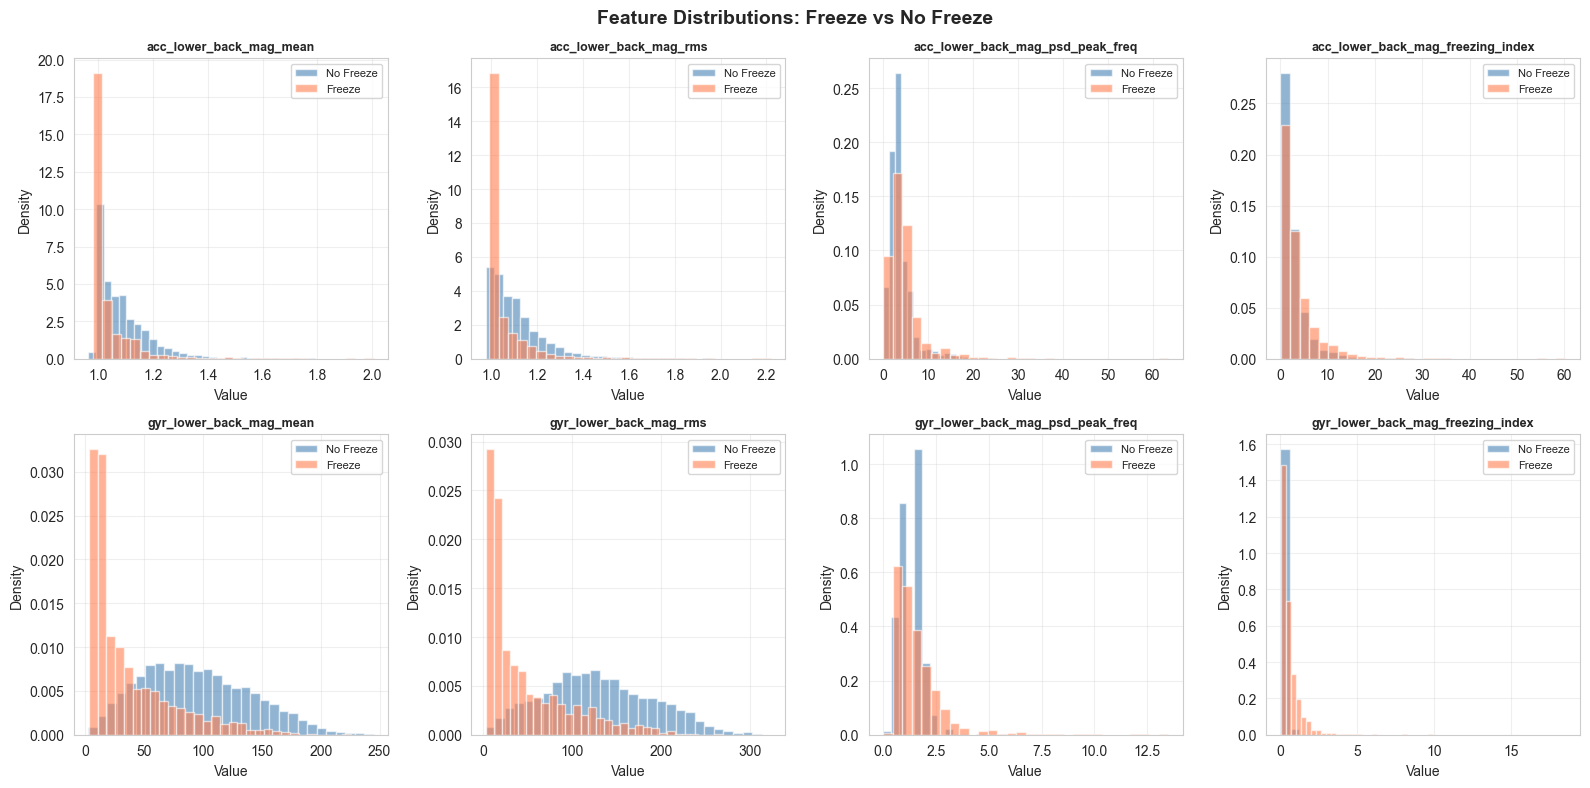

In [8]:
# Separate by class (replace inf so histograms and Cohen's d are not distorted)
features_no_freeze = X_train_features[y_train == 0].replace([np.inf, -np.inf], np.nan)
features_freeze    = X_train_features[y_train == 1].replace([np.inf, -np.inf], np.nan)

print(f"📊 Class Distribution:")
print(f"   No Freeze: {len(features_no_freeze):,} windows ({len(features_no_freeze)/len(X_train_features)*100:.1f}%)")
print(f"   Freeze: {len(features_freeze):,} windows ({len(features_freeze)/len(X_train_features)*100:.1f}%)")

# Select representative features (per-group magnitudes)
feature_subset = [
    'acc_lower_back_mag_mean', 'acc_lower_back_mag_rms',
    'acc_lower_back_mag_psd_peak_freq', 'acc_lower_back_mag_freezing_index',
    'gyr_lower_back_mag_mean', 'gyr_lower_back_mag_rms',
    'gyr_lower_back_mag_psd_peak_freq', 'gyr_lower_back_mag_freezing_index',
]

# Filter to existing features
feature_subset = [f for f in feature_subset if f in X_train_features.columns]

# Visualize distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feat in enumerate(feature_subset[:8]):
    axes[i].hist(features_no_freeze[feat].dropna(), bins=30, alpha=0.6, 
                label='No Freeze', color='steelblue', density=True)
    axes[i].hist(features_freeze[feat].dropna(), bins=30, alpha=0.6, 
                label='Freeze', color='coral', density=True)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

# Hide unused subplots
for i in range(len(feature_subset), 8):
    axes[i].axis('off')

plt.suptitle('Feature Distributions: Freeze vs No Freeze', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance by Variance

Identify features with highest variance (potentially most discriminative).

📊 Top 15 Features by Variance:
 1. gyr_lower_back_mag_wavelet_energy_0 26706172041236.81
 2. ch5_wavelet_energy_0                18376102117037.61
 3. ch4_wavelet_energy_0                303944956598.30
 4. ch3_wavelet_energy_0                203032359848.03
 5. ch5_wavelet_energy_1                62830428697.17
 6. ch5_wavelet_energy_2                20063800933.86
 7. gyr_lower_back_mag_wavelet_energy_1 12435052204.05
 8. ch5_wavelet_energy_3                7826454938.61
 9. ch5_wavelet_var_0                   6720570628.12
10. gyr_lower_back_mag_wavelet_var_0    3597859236.27
11. gyr_lower_back_mag_wavelet_energy_2 2022361809.88
12. gyr_lower_back_mag_wavelet_energy_3 1206910737.20
13. ch4_wavelet_energy_1                991155743.55
14. ch3_wavelet_energy_1                895701537.40
15. ch3_wavelet_energy_2                554095754.58


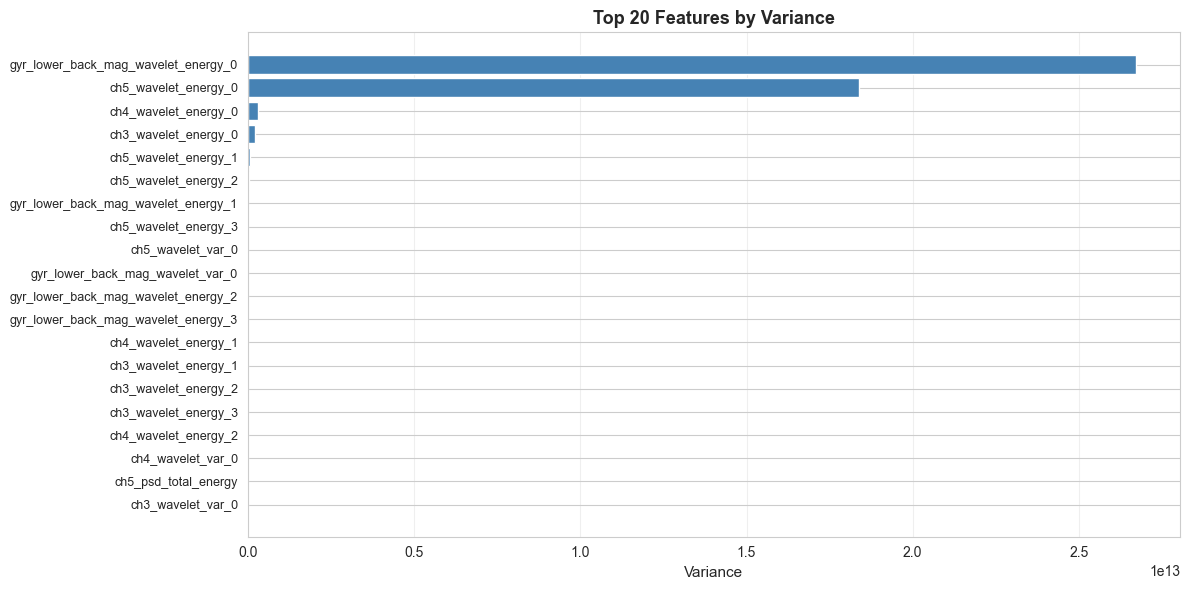

In [9]:
# Calculate variance for each feature (replace inf with NaN before var to avoid inf results)
feature_variance = (
    X_train_features
    .replace([np.inf, -np.inf], np.nan)
    .var()
    .sort_values(ascending=False)
)

print("📊 Top 15 Features by Variance:")
print("=" * 60)
for i, (feat, var) in enumerate(feature_variance.head(15).items(), 1):
    print(f"{i:2d}. {feat:35s} {var:12.2f}")

# Visualize top features by variance
fig, ax = plt.subplots(figsize=(12, 6))
top_features = feature_variance.dropna().head(20)
ax.barh(range(len(top_features)), top_features.values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index, fontsize=9)
ax.set_xlabel('Variance', fontsize=11)
ax.set_title('Top 20 Features by Variance', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Feature Correlation Analysis

Identify highly correlated features (potential redundancy).

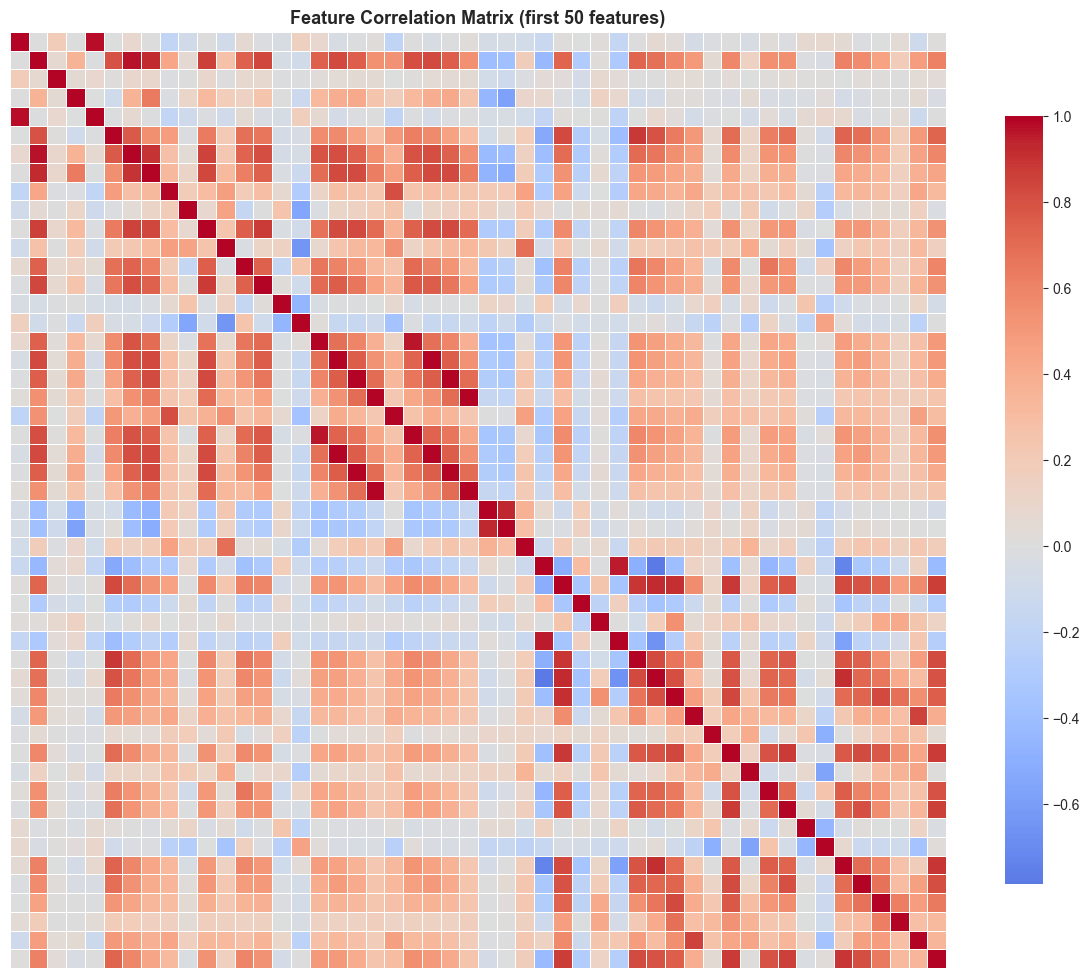


⚠️  Highly correlated pairs (|r| > 0.9): 12

Top 10 correlations:
  ch0_wavelet_energy_3           <-> ch0_wavelet_var_3             :  1.000
  ch0_wavelet_energy_2           <-> ch0_wavelet_var_2             :  1.000
  ch0_wavelet_energy_1           <-> ch0_wavelet_var_1             :  1.000
  ch0_mean                       <-> ch0_median                    :  0.973
  ch0_std                        <-> ch0_rms                       :  0.970
  ch0_wavelet_energy_0           <-> ch0_wavelet_var_0             :  0.962
  ch1_mean                       <-> ch1_median                    :  0.951
  ch0_sample_entropy             <-> ch0_approx_entropy            :  0.930
  ch0_std                        <-> ch0_peak_to_peak              :  0.920
  ch1_std                        <-> ch1_rms                       :  0.918


In [10]:
# Compute correlation matrix (replace inf with NaN before corr to avoid propagation)
n_features_viz = min(50, X_train_features.shape[1])
features_sample = (
    X_train_features
    .replace([np.inf, -np.inf], np.nan)
    .iloc[:, :n_features_viz]
)
corr_matrix = features_sample.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
           square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
           xticklabels=False, yticklabels=False)
ax.set_title(f'Feature Correlation Matrix (first {n_features_viz} features)', 
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if np.isfinite(val) and abs(val) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                val
            ))

print(f"\n⚠️  Highly correlated pairs (|r| > {high_corr_threshold}): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nTop 10 correlations:")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1:30s} <-> {feat2:30s}: {corr:6.3f}")

## 9. Class Separability Analysis

Measure how well features separate Freeze from No Freeze using effect size (Cohen's d).

📊 Top 15 Features by Effect Size (Cohen's d):
   Higher effect size = better class separability
   d > 0.8: Large effect
   d > 0.5: Medium effect
   d > 0.2: Small effect
 1. ch5_sample_entropy                  d=1.679  (Large)
 2. gyr_lower_back_mag_sample_entropy   d=1.646  (Large)
 3. gyr_lower_back_mag_std              d=1.477  (Large)
 4. ch5_approx_entropy                  d=1.460  (Large)
 5. ch5_rms                             d=1.452  (Large)
 6. ch5_std                             d=1.443  (Large)
 7. gyr_lower_back_mag_rms              d=1.411  (Large)
 8. gyr_lower_back_mag_approx_entropy   d=1.383  (Large)
 9. gyr_lower_back_mag_locomotion_band_index d=1.381  (Large)
10. gyr_lower_back_mag_peak_to_peak     d=1.346  (Large)
11. gyr_lower_back_mag_mean             d=1.319  (Large)
12. ch5_peak_to_peak                    d=1.271  (Large)
13. gyr_lower_back_mag_iqr              d=1.213  (Large)
14. gyr_lower_back_mag_spectral_centroid d=1.205  (Large)
15. ch5_locomotion_band_

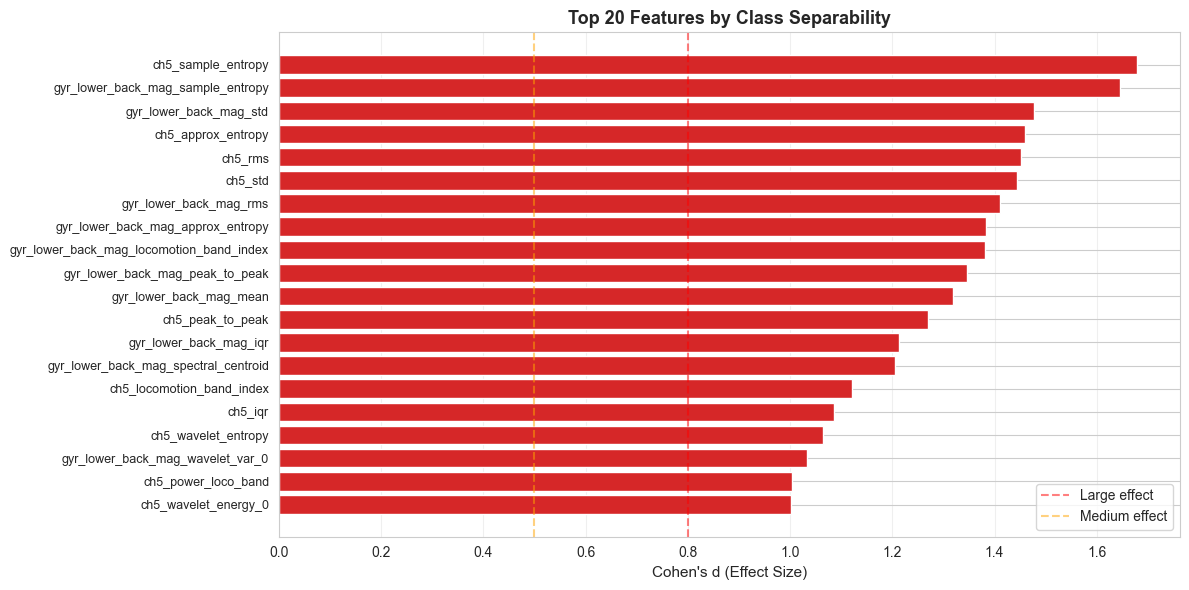

In [11]:
# Calculate Cohen's d for each feature
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    mean1, mean2 = group1.mean(), group2.mean()
    std1, std2 = group1.std(), group2.std()
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))
    return abs((mean1 - mean2) / pooled_std) if pooled_std > 0 else 0

effect_sizes = {}
for col in X_train_features.columns:
    d = cohens_d(features_no_freeze[col].dropna(), features_freeze[col].dropna())
    effect_sizes[col] = d

effect_sizes = pd.Series(effect_sizes).sort_values(ascending=False)

print("📊 Top 15 Features by Effect Size (Cohen's d):")
print("=" * 70)
print("   Higher effect size = better class separability")
print("   d > 0.8: Large effect")
print("   d > 0.5: Medium effect")
print("   d > 0.2: Small effect")
print("=" * 70)
for i, (feat, d) in enumerate(effect_sizes.head(15).items(), 1):
    magnitude = "Large" if d > 0.8 else "Medium" if d > 0.5 else "Small" if d > 0.2 else "Negligible"
    print(f"{i:2d}. {feat:35s} d={d:5.3f}  ({magnitude})")

# Visualize top features by effect size
fig, ax = plt.subplots(figsize=(12, 6))
top_effects = effect_sizes.head(20)
colors = ['#d62728' if d > 0.8 else '#ff7f0e' if d > 0.5 else '#2ca02c' for d in top_effects.values]
ax.barh(range(len(top_effects)), top_effects.values, color=colors)
ax.set_yticks(range(len(top_effects)))
ax.set_yticklabels(top_effects.index, fontsize=9)
ax.set_xlabel("Cohen's d (Effect Size)", fontsize=11)
ax.set_title('Top 20 Features by Class Separability', fontsize=13, fontweight='bold')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Large effect')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium effect')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Summary

In [ ]:
# Summary statistics
total_train = sum(len(fold['y_train']) for fold in loso_splits)
total_test = sum(len(fold['y_test']) for fold in loso_splits)
expected_fold_dirs = {f"fold_subj_{fold['test_subject']}" for fold in loso_splits}
existing_fold_dirs = {path.name for path in feature_output_dir.glob('fold_subj_*') if path.is_dir()}
missing_fold_dirs = sorted(expected_fold_dirs - existing_fold_dirs)

print('=' * 70)
print('FEATURE EXTRACTION SUMMARY')
print('=' * 70)

print(f'\n📊 Feature Configuration:')
print(f'   Time-domain: ✅ Enabled')
print(f'   Frequency-domain: ✅ Enabled')
print(f'   Wavelet: ✅ Enabled')
print(f'   Nonlinear: ✅ Enabled')

print(f'\n📈 Processing Statistics:')
print(f'   LOSO folds: {len(loso_splits)}')
print(f'   Total train windows: {total_train:,}')
print(f'   Total test windows: {total_test:,}')
print(f'   Features per window: {X_train_features.shape[1]}')

print(f'\n🧪 Signal Preparation:')
print('   Source windows: raw outputs from notebook 02')
print('   Outlier cleaning: disabled')
print('   Aggressive interpolation: disabled')
print('   Non-finite feature values: sanitized to NaN by FeatureExtractor')
print('   Downstream handling: notebook 04 imputes missing values during training')

print(f'\n💾 Output:')
print(f'   Directory: {feature_output_dir}')
print('   Files per fold: X_train_features.csv, y_train.csv, subjects_train.csv, X_test_features.csv, y_test.csv')
print(f'   Existing fold directories: {len(existing_fold_dirs)}')
if missing_fold_dirs:
    print(f'   Missing fold directories: {len(missing_fold_dirs)}')
    for name in missing_fold_dirs[:10]:
        print(f'     - {name}')
    if len(missing_fold_dirs) > 10:
        print(f'     ... and {len(missing_fold_dirs) - 10} more')
else:
    print('   Output integrity: all expected fold directories are present')

print(f'\n🎯 Key Insights:')
print(f'   Top feature (variance): {feature_variance.index[0]}')
print(f'   Top feature (effect size): {effect_sizes.index[0]} (d={effect_sizes.iloc[0]:.3f})')
print(f'   Highly correlated pairs: {len(high_corr_pairs)}')

print('\n' + '=' * 70)
print('✅ Dataset ready for training!')
print('📌 Next step: Run notebook 04_loso_pipeline_and_training.ipynb')
print('=' * 70)

FEATURE EXTRACTION SUMMARY

📊 Feature Configuration:
   Time-domain: ✅ Enabled
   Frequency-domain: ✅ Enabled
   Wavelet: ✅ Enabled
   Nonlinear: ✅ Enabled

📈 Processing Statistics:
   LOSO folds: 26
   Total train windows: 213,367
   Total test windows: 3,180
   Features per window: 225

🧹 Signal Cleaning:
   Method: conservative MAD-based outlier detection
   Interpolation: linear (outliers + missing values)
   Threshold: 4.5 × MAD
   Max outlier fraction/channel: 0.15
   Max missing fraction/channel: 0.20

💾 Output:
   Directory: ..\..\outputs\figshare_features
   Files per fold: X_train_features.csv, y_train.csv, X_test_features.csv, y_test.csv

🎯 Key Insights:
   Top feature (variance): gyr_lower_back_mag_wavelet_energy_0
   Top feature (effect size): ch5_sample_entropy (d=1.679)
   Highly correlated pairs: 12

✅ Dataset ready for training!
📌 Next step: Run notebook 04_loso_pipeline_and_training.ipynb


## 11. Raw Model Training for Preprocessing Experiments

This section adds a **fast LOSO baseline** to evaluate preprocessing choices directly from the extracted feature CSVs.

**Design goals:**
- no hyperparameter tuning
- no feature selection
- fixed, simple models
- configurable preprocessing steps so you can compare variants quickly

Edit the configuration cell below to experiment with imputation, scaling, and resampling.